# IPL Data Analysis 

In [5]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import warnings
warnings.filterwarnings("ignore")


In [7]:
df = pd.read_csv("IPL.csv")
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [8]:
df.info() # it is used for information of out dataset


<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [9]:
print(f"rows: {df.shape[0]} and cols are {df.shape[1]}")

rows: 74 and cols are 20


In [10]:
df.isnull().sum() # by doing this we can sea that how many null values are there in each column 

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### Which team won the most matches 

Text(0.5, 1.0, 'Most Match Winner')

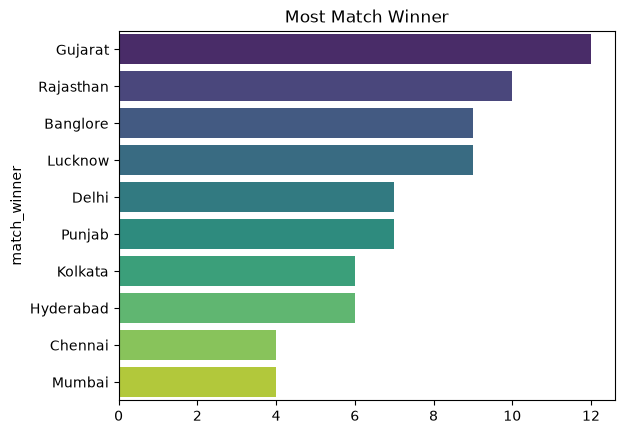

In [11]:
matchWins = df['match_winner'].value_counts()
sns.barplot(y = matchWins.index , x = matchWins.values , palette='viridis' )
plt.title("Most Match Winner")

## Toss Dicision Trends

#### Graph which tells us about what is the decision of team after winning toss

<Axes: xlabel='toss_decision', ylabel='count'>

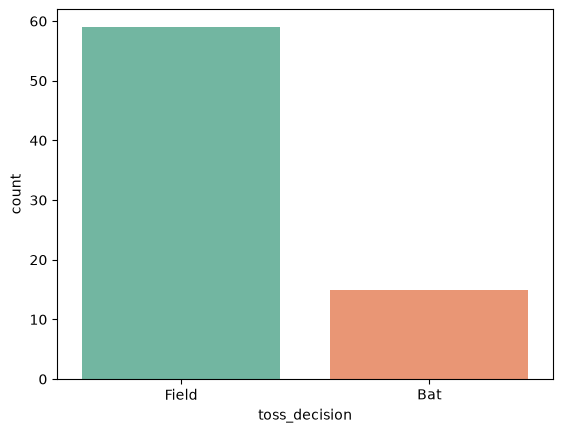

In [12]:
sns.countplot(x = df['toss_decision'] , palette='Set2')

#### how many choose field or bat after winning the toss 

In [13]:
field = df[df['toss_decision'] == 'Field']['match_id'].count()
bat = df[df['toss_decision'] == 'Bat']['match_id'].count()

field_per = field/df['match_id'].count()*100
bat_per = bat/df['match_id'].count()*100

print(field_per)
print(bat_per)


79.72972972972973
20.27027027027027


#### Percentage of all matches where the team won the toss, chose to field, and won the match

In [14]:
winOfBowlFirst = df[(df['toss_winner'] == df['match_winner']) & (df['toss_decision'] == 'Field')]['match_id'].count()
winOfBowlFirst/len(df)*100

np.float64(39.189189189189186)

#### Success percentage when choosing Field.

In [24]:
Success_percentage_when_choosing_Field = round(df[(df['match_winner'] == df['toss_winner']) & (df['toss_decision'] == 'Field')]['match_id'].count()/df['match_id'].count()*100,2)


print(Success_percentage_when_choosing_Field)

39.19


### Toss Winner vs Match Winner

In [15]:
df[df['toss_winner'] == df['match_winner']].head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
5,6,"March 30,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Kolkata,Group,Banglore,Field,128,10,132,7,Banglore,Wickets,3,Wanindu Hasaranga,Sherfane Rutherford,28,Wanindu Hasaranga,4--20


In [16]:
tossAndMatch = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
total = df['match_id'].count()

per = tossAndMatch/total*100
per = round(per,2)

print(f"Percentage of teams which won both match and toss: {per}%") 

Percentage of teams which won both match and toss: 48.65%


### How many matches were won by the team that lost the toss?

In [17]:
tossButNOtMatch = df[df['toss_winner'] != df['match_winner']]
tossButNOtMatch['match_id'].count()

np.int64(38)

### How many matches each team played.

In [18]:
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [19]:
total_matches = pd.concat([df['team1'],df['team2']])
total_matches.value_counts()

Rajasthan    17
Banglore     16
Gujarat      16
Lucknow      15
Chennai      14
Delhi        14
Hyderabad    14
Kolkata      14
Mumbai       14
Punjab       14
Name: count, dtype: int64

#### 

### How many matches were won by the team batting first.

In [21]:
wonByBatFirst = df[df['won_by'] == 'Runs']['match_id'].count()

wonByBatFirstPer = wonByBatFirst/total*100

print(wonByBatFirstPer)

50.0


### How many matches were won by the team batting second (chasing).

In [22]:
wonByFieldFirst = df[df['won_by'] == 'Wickets']['match_id'].count()

wonByFieldFirstPer = wonByFieldFirst/total*100

print(wonByFieldFirstPer)

50.0


## Home Advantage

#### Find the top 5 venues with the highest number of matches played.

In [27]:
highest_matches_played = df['venue'].value_counts()
highest_matches_played.head(5)

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Name: count, dtype: int64

##### For each of those 5 venues, find the number of matches won by the team batting first.

In [37]:
wickets_only = df[df['won_by'] == 'Wickets']['venue'].value_counts()
print(wickets_only)

venue
Wankhede Stadium, Mumbai                        13
Dr DY Patil Sports Academy, Mumbai              10
Brabourne Stadium, Mumbai                        8
Maharashtra Cricket Association Stadium,Pune     3
Narendra Modi Stadium, Ahmedabad                 2
Eden Gardens, Kolkata                            1
Name: count, dtype: int64


#### Calculate the chasing win percentage for each venue.

In [38]:
top5 = highest_matches_played

chasing_percentage = (wickets_only / top5) * 100

print(chasing_percentage)

venue
Brabourne Stadium, Mumbai                        50.000000
Dr DY Patil Sports Academy, Mumbai               50.000000
Eden Gardens, Kolkata                            50.000000
Maharashtra Cricket Association Stadium,Pune     23.076923
Narendra Modi Stadium, Ahmedabad                100.000000
Wankhede Stadium, Mumbai                         61.904762
Name: count, dtype: float64


#### Observations 

###### in 50% of total matches who bat first were won 
###### total 29 matches from 74 won by the team who won the toss and choose Field